# Visualization

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _resolve_eval_json(target_rel: str | Path):
    target_rel = Path(target_rel)

    # Support both full relative paths and bare filenames.
    search_candidates = [target_rel]
    if not target_rel.is_absolute() and target_rel.parent == Path("."):
        search_candidates.extend(
            [
                Path("data/llm_eval_results_compare/comparison_llm_eval_results") / target_rel,
                Path("data/comparison_llm_eval_results") / target_rel,
            ]
        )

    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in search_candidates:
            candidate = base / rel
            if candidate.exists():
                resolved = candidate
                break
        if resolved is not None:
            break

    if resolved is None:
        attempted = ", ".join(str(p) for p in search_candidates)
        raise FileNotFoundError(
            f"Cannot find any of [{attempted}]. Current working directory: {Path.cwd()}"
        )

    with resolved.open("r", encoding="utf-8") as f:
        return resolved, json.load(f)


def plot_eval_results(
    target_rel: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results/self_generated_test_cases_eval.json",
    runs_per_query: int = 5,
):
    resolved, data = _resolve_eval_json(target_rel)

    results = data["results"]
    sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))

    metric_series = {
        "policy_faithfulness": np.array(
            [results[k].get("policy", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_answer_relevance": np.array(
            [results[k].get("policy", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "policy_correctness": np.array(
            [results[k].get("policy", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_faithfulness": np.array(
            [results[k].get("provider", {}).get("faithfulness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_answer_relevance": np.array(
            [results[k].get("provider", {}).get("answer_relevance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "provider_correctness": np.array(
            [results[k].get("provider", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "query_alignment": np.array(
            [results[k].get("query_alignment", {}).get("comparison_query_relevance", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "correctness": np.array(
            [results[k].get("compare_quality", {}).get("correctness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_sim": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_sim", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "accuracy_diff": np.array(
            [results[k].get("compare_quality", {}).get("accuracy_diff", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "completeness": np.array(
            [results[k].get("compare_quality", {}).get("completeness", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "balance": np.array(
            [results[k].get("compare_quality", {}).get("balance", {}).get("score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "comparison_overall_score": np.array(
            [results[k].get("comparison_overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
        "overall_score": np.array(
            [results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        ),
    }

    plot_metrics = [
        "policy_faithfulness",
        "policy_answer_relevance",
        "policy_correctness",
        "provider_faithfulness",
        "provider_answer_relevance",
        "provider_correctness",
        "query_alignment",
        "correctness",
        "accuracy_sim",
        "accuracy_diff",
        "completeness",
        "balance",
        "comparison_overall_score",
        "overall_score",
    ]

    print(f"Loaded from: {resolved}")
    print(f"Total cases: {len(sorted_keys)}")
    print(f"Runs per query: {runs_per_query}")

    fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 4 * len(plot_metrics)), sharex=False)
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, metric_name in zip(axes, plot_metrics):
        values = np.asarray(metric_series[metric_name], dtype=float)
        usable = values[: (len(values) // runs_per_query) * runs_per_query]
        grouped = usable.reshape(-1, runs_per_query)

        means = grouped.mean(axis=1)
        stds = grouped.std(axis=1)
        x = np.arange(len(means))

        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='black', label='Mean ± Std', zorder=3)

        for i in range(grouped.shape[0]):
            jitter = np.random.normal(i, 0.05, size=grouped.shape[1])
            if i == 0:
                ax.scatter(jitter, grouped[i], alpha=0.6, label='Individual Runs', zorder=2)
            else:
                ax.scatter(jitter, grouped[i], alpha=0.6, zorder=2)

        ax.set_xlabel("Query ID")
        ax.set_ylabel("Score")
        ax.set_title(f"{metric_name} Stability and Distribution Across {runs_per_query} Runs")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(len(means))])
        ax.legend()
        ax.grid(True, axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()
    return resolved, metric_series


## dense_sparse

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval.json
Total cases: 60
Runs per query: 5


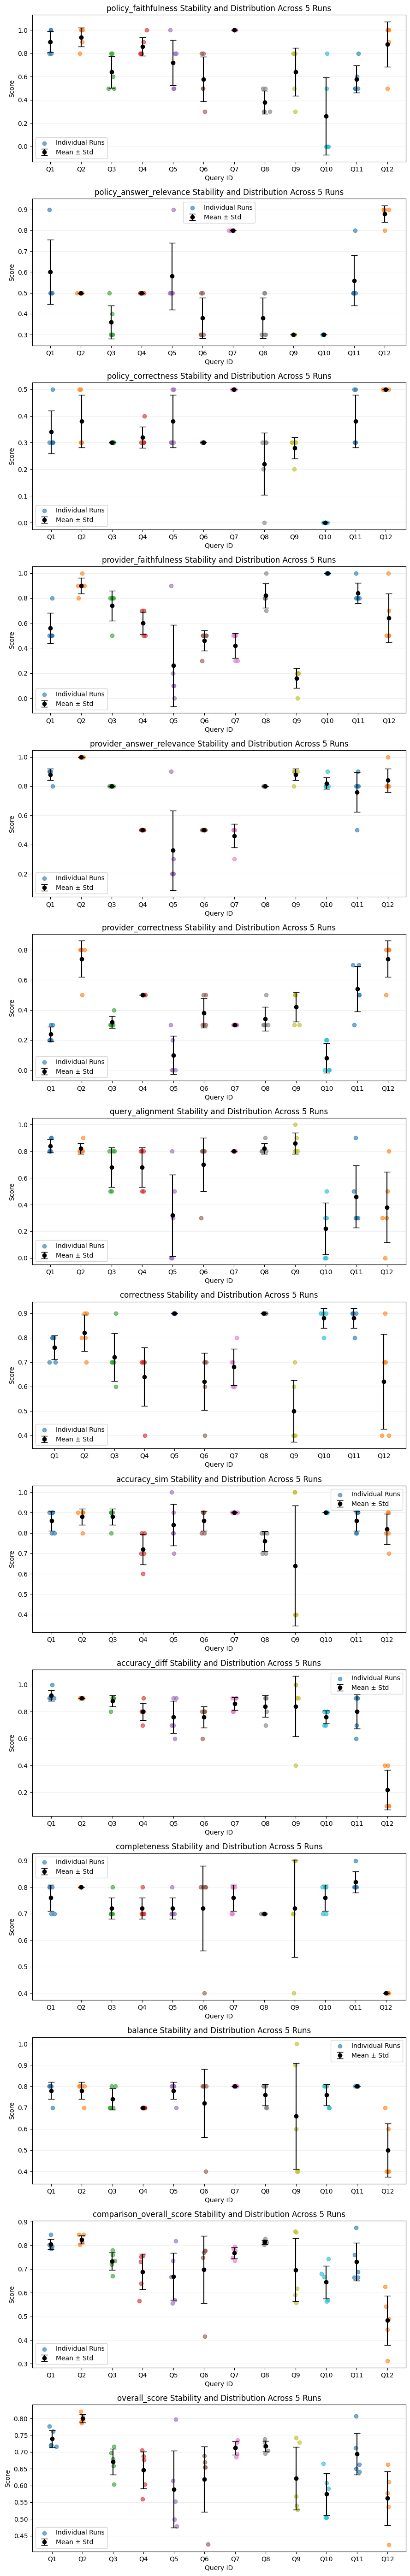

In [21]:
resolved, metric_series = plot_eval_results("dense_sparse_llm_eval.json")

## llm_extract

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval.json
Total cases: 60
Runs per query: 5


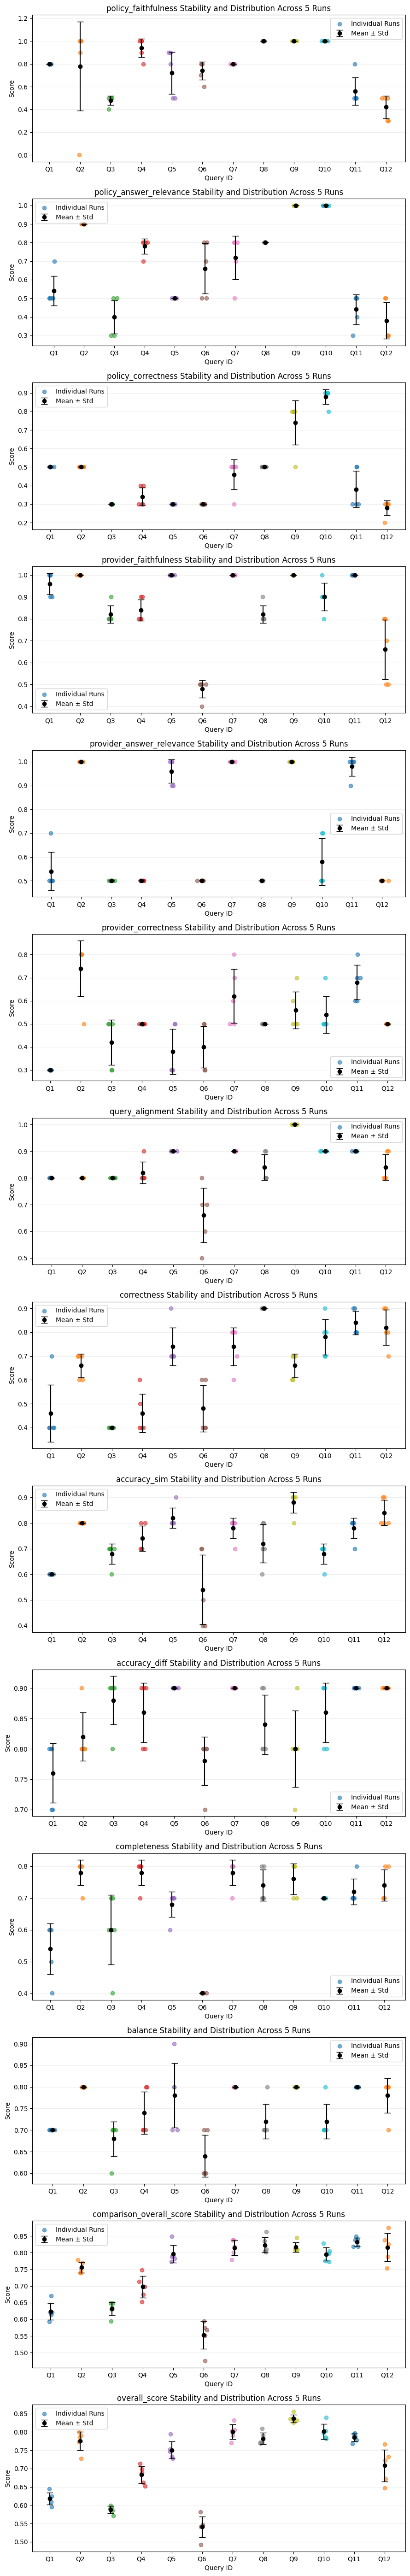

In [23]:
resolved, metric_series = plot_eval_results("llm_extract_llm_eval.json")

## theme_aware

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval.json
Total cases: 60
Runs per query: 5


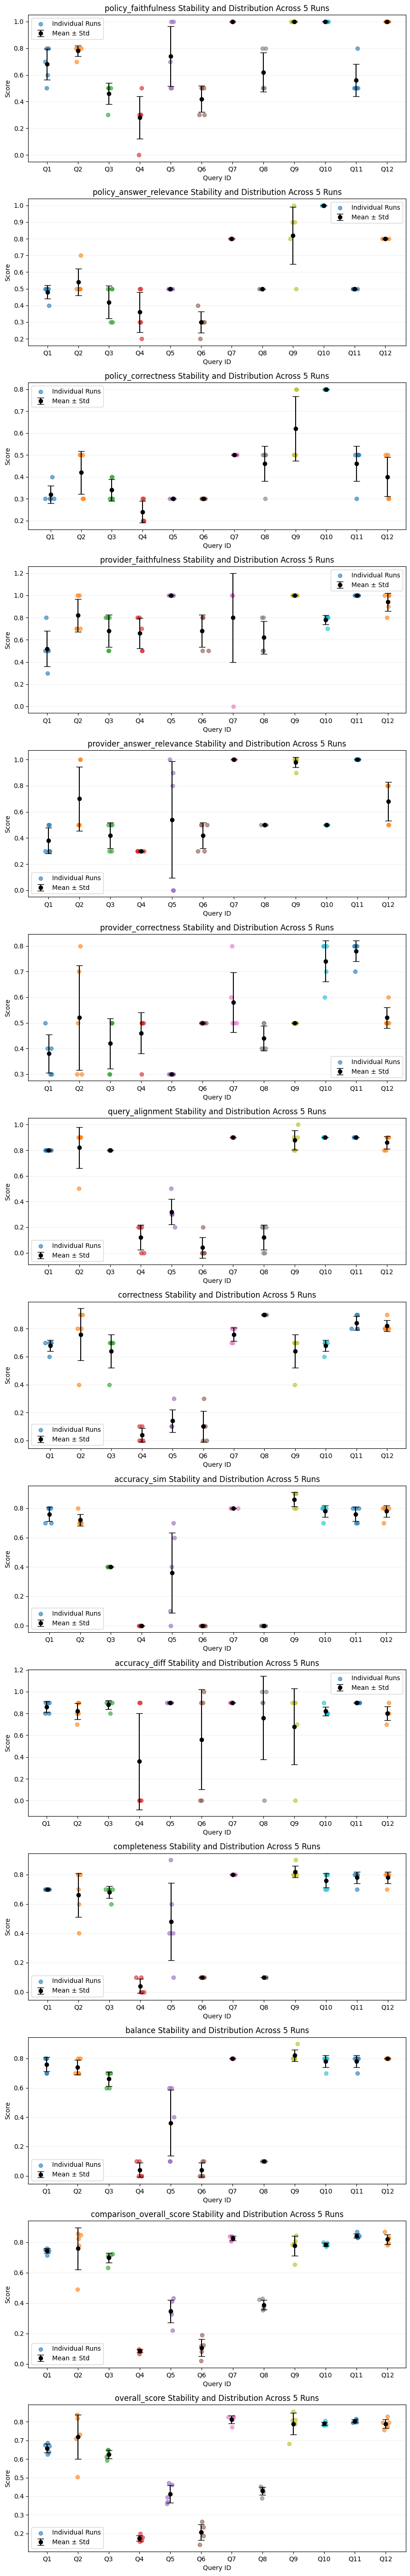

In [40]:
resolved, metric_series = plot_eval_results("theme_aware_llm_eval.json")

# Aggregated Visualization

Loaded 3 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
  dense_sparse_llm_eval: n=60, mean=0.662
  llm_extract_llm_eval: n=60, mean=0.722
  theme_aware_llm_eval: n=60, mean=0.601


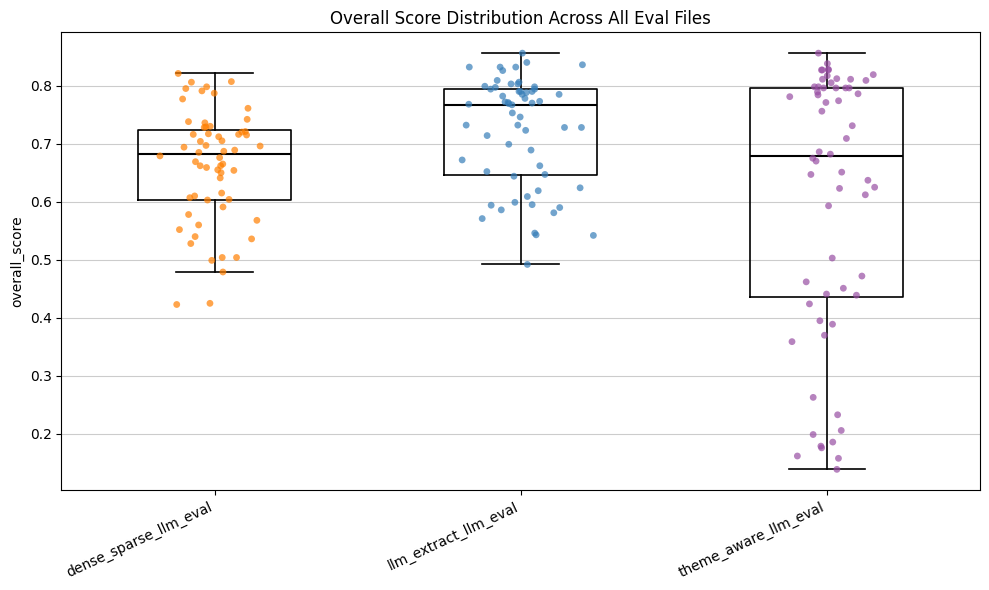

In [41]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np



def _resolve_eval_dir(target_dir: str | Path):
    target_dir = Path(target_dir)
    resolved = None
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / target_dir
        if candidate.exists():
            resolved = candidate
            break

    if resolved is None:
        raise FileNotFoundError(
            f"Cannot find {target_dir}. Current working directory: {Path.cwd()}"
        )

    return resolved



def plot_all_files_overall_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(resolved_dir.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_scores = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        scores = [
            record.get("overall_score", np.nan)
            for record in results.values()
            if isinstance(record, dict)
        ]
        scores = np.asarray(scores, dtype=float)
        scores = scores[~np.isnan(scores)]
        file_scores[file_path.stem] = scores

    labels = list(file_scores.keys())
    values = [file_scores[label] for label in labels]

    print(f"Loaded {len(labels)} files from: {resolved_dir}")
    for label, scores in file_scores.items():
        print(f"  {label}: n={len(scores)}, mean={scores.mean():.3f}" if len(scores) else f"  {label}: n=0")

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.8), 6))
    positions = np.arange(1, len(labels) + 1)
    colors = [
        "#ff7f00",
        "#377eb8",
        "#984ea3",
        "#a65628",
        "#f781bf",
        "#999999",
        "#66c2a5"
    ]

    box = ax.boxplot(
        values,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=False,
        zorder=1,
    )
    for line in box["boxes"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["whiskers"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["caps"]:
        line.set_color("black")
        line.set_linewidth(1.2)
    for line in box["medians"]:
        line.set_color("black")
        line.set_linewidth(1.5)

    for idx, scores in enumerate(values, start=1):
        if len(scores) == 0:
            continue
        jitter = np.random.normal(idx, 0.08, size=len(scores))
        ax.scatter(
            jitter,
            scores,
            alpha=0.7,
            s=24,
            color=colors[(idx - 1) % len(colors)],
            edgecolors="none",
            zorder=3,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="black")
    ax.set_ylabel("overall_score", color="black")
    ax.set_title("Overall Score Distribution Across All Eval Files", color="black")
    ax.grid(True, axis="y", alpha=0.2, color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    return file_scores


file_scores = plot_all_files_overall_scores()

Loaded 3 files from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results
Queries per file: 12
Runs per query: 5


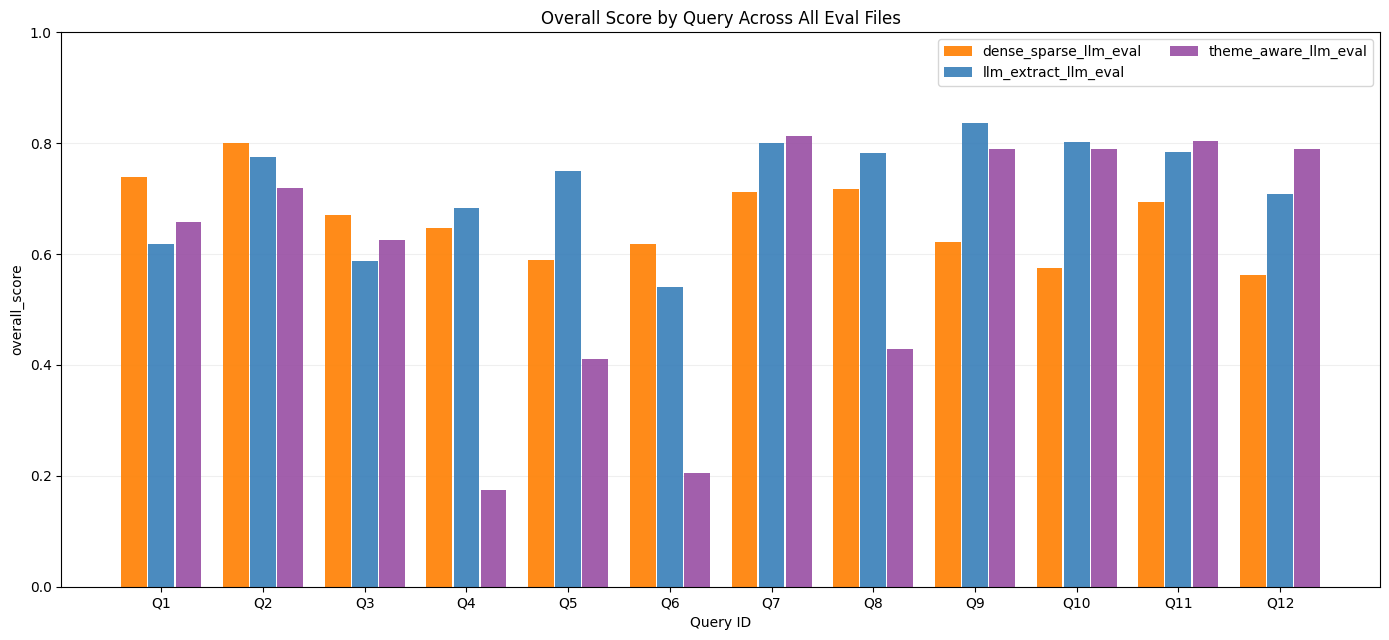

In [42]:
def plot_overall_scores_by_query(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    runs_per_query: int = 5,
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(resolved_dir.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    file_names = [file_path.stem for file_path in files]
    file_series = []
    query_count = None

    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        results = data.get("results", {})
        sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))
        scores = np.array(
            [results[k].get("overall_score", np.nan) for k in sorted_keys],
            dtype=float,
        )
        scores = scores[~np.isnan(scores)]
        usable = scores[: (len(scores) // runs_per_query) * runs_per_query]
        if usable.size == 0:
            continue

        grouped = usable.reshape(-1, runs_per_query)
        query_means = grouped.mean(axis=1)

        if query_count is None:
            query_count = len(query_means)
        else:
            query_count = min(query_count, len(query_means))

        file_series.append(query_means)

    if query_count is None or query_count == 0:
        raise ValueError("No overall_score values found in the selected files")

    query_count = int(query_count)
    file_series = [means[:query_count] for means in file_series]
    query_labels = [f"Q{i+1}" for i in range(query_count)]

    print(f"Loaded {len(file_series)} files from: {resolved_dir}")
    print(f"Queries per file: {query_count}")
    print(f"Runs per query: {runs_per_query}")

    fig, ax = plt.subplots(figsize=(max(14, query_count * 1.1), 6.5))
    x = np.arange(query_count)
    n_files = len(file_names)
    group_width = 0.8
    bar_width = group_width / max(n_files, 1)
    offsets = (np.arange(n_files) - (n_files - 1) / 2) * bar_width
    colors = [
        "#ff7f00",
        "#377eb8",
        "#984ea3",
        "#a65628",
        "#f781bf",
        "#999999",
        "#66c2a5"
    ]

    for file_idx, (file_name, means) in enumerate(zip(file_names, file_series)):
        positions = x + offsets[file_idx]
        ax.bar(
            positions,
            means,
            width=bar_width * 0.95,
            alpha=0.9,
            color=colors[file_idx % len(colors)],
            label=file_name,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(query_labels)
    ax.set_xlabel("Query ID")
    ax.set_ylabel("overall_score")
    ax.set_title("Overall Score by Query Across All Eval Files")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.2)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    return file_names, file_series


file_names, file_series = plot_overall_scores_by_query()

# Convert to Readable (CSV)

## Score Only

In [43]:
import csv


def export_flat_scores(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(resolved_dir.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        results = data["results"]
        sorted_keys = sorted(results.keys(), key=lambda x: int(x.split("_")[-1]))

        rows = []
        for test_id in sorted_keys:
            record = results[test_id]
            policy = record.get("policy", {})
            provider = record.get("provider", {})
            query_alignment = record.get("query_alignment", {})
            compare_quality = record.get("compare_quality", {})

            row = {
                "test_id": test_id,
                "query": record.get("query", ""),
                "answer": record.get("answer", ""),
                "policy_faithfulness": policy.get("faithfulness", {}).get("score", ""),
                "policy_answer_relevance": policy.get("answer_relevance", {}).get("score", ""),
                "policy_correctness": policy.get("correctness", {}).get("score", ""),
                "provider_faithfulness": provider.get("faithfulness", {}).get("score", ""),
                "provider_answer_relevance": provider.get("answer_relevance", {}).get("score", ""),
                "provider_correctness": provider.get("correctness", {}).get("score", ""),
                "query_alignment": query_alignment.get("comparison_query_relevance", ""),
                "correctness": compare_quality.get("correctness", {}).get("score", ""),
                "accuracy_sim": compare_quality.get("accuracy_sim", {}).get("score", ""),
                "accuracy_diff": compare_quality.get("accuracy_diff", {}).get("score", ""),
                "completeness": compare_quality.get("completeness", {}).get("score", ""),
                "balance": compare_quality.get("balance", {}).get("score", ""),
                "comparison_overall_score": record.get("comparison_overall_score", ""),
                "overall_score": record.get("overall_score", ""),
            }
            rows.append(row)

        csv_path = file_path.with_name(file_path.stem + "_flat_scores.csv")
        fieldnames = list(rows[0].keys()) if rows else []

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")

    return exported


exported_csvs = export_flat_scores()


Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval_flat_scores.csv
Rows written: 60
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval_flat_scores.csv
Rows written: 60


## Include Reasons

In [ ]:
def _flatten_record(value, parent_key="", sep="."):
    flat = {}

    if isinstance(value, dict):
        for k, v in value.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
            flat.update(_flatten_record(v, new_key, sep=sep))
    elif isinstance(value, list):
        # Keep lists as JSON strings so variable-length arrays stay in one column.
        flat[parent_key] = json.dumps(value, ensure_ascii=False)
    else:
        flat[parent_key] = value

    return flat


def export_all_query_fields_to_csv(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(resolved_dir.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        results = data.get("results", {})
        # Keep JSON insertion order; do not sort test ids.
        key_order = list(results.keys())

        rows = []
        ordered_columns = ["test_id"]

        for test_id in key_order:
            record = results.get(test_id, {})
            flat_record = _flatten_record(record)
            row = {"test_id": test_id, **flat_record}
            rows.append(row)

            for col in row.keys():
                if col not in ordered_columns:
                    ordered_columns.append(col)

        fieldnames = ordered_columns
        csv_path = file_path.with_name(file_path.stem + "_all_fields.csv")

        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({k: row.get(k, "") for k in fieldnames})

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")
        print(f"Columns written: {len(fieldnames)}")

    return exported


all_fields_csvs = export_all_query_fields_to_csv()
all_fields_csvs

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval_all_fields.csv
Rows written: 60
Columns written: 43
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval_all_fields.csv
Rows written: 60
Columns written: 45
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval_all_fields.csv
Rows written: 60
Columns wr

{'dense_sparse_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval_all_fields.csv'),
 'llm_extract_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval_all_fields.csv'),
 'theme_aware_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval_all_fields.csv')}

## Reasons when score < 0.6

In [57]:
def _to_float_or_none(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _score_first_dict(d: dict):
    if not isinstance(d, dict) or "score" not in d:
        return d
    ordered = {"score": d.get("score")}
    for k, v in d.items():
        if k == "score":
            continue
        ordered[k] = v
    return ordered


def _flatten_fields_in_order(value, parent_key=""):
    """Flatten nested fields while preserving insertion order."""
    flat = {}

    if isinstance(value, dict):
        for k, v in value.items():
            # Skip schema blocks entirely.
            if k == "schema":
                continue

            new_key = f"{parent_key}.{k}" if parent_key else str(k)
            if isinstance(v, dict):
                flat.update(_flatten_fields_in_order(v, new_key))
            elif isinstance(v, list):
                flat[new_key] = json.dumps(v, ensure_ascii=False)
            else:
                flat[new_key] = v
    elif isinstance(value, list):
        flat[parent_key] = json.dumps(value, ensure_ascii=False)
    else:
        flat[parent_key] = value

    return flat


def _collect_scored_columns_in_order(value, threshold=0.6, parent_key=""):
    """
    Traverse nested dicts in JSON order and collect columns for each scored item.
    - score column is always kept
    - non-score fields are kept only when score < threshold, otherwise set to empty
    """
    columns = []

    if not isinstance(value, dict):
        return columns

    score = _to_float_or_none(value.get("score")) if "score" in value else None
    if score is not None:
        key_prefix = parent_key or "item"
        full_item = _score_first_dict(value)
        flat_item = _flatten_fields_in_order(full_item)

        for sub_key, sub_value in flat_item.items():
            # Safety filter: do not export schema columns.
            if sub_key == "schema" or sub_key.endswith(".schema") or ".schema." in sub_key:
                continue

            col_name = f"{key_prefix}.{sub_key}" if sub_key else key_prefix
            if col_name == "schema" or col_name.endswith(".schema") or ".schema." in col_name:
                continue

            if sub_key == "score":
                columns.append((col_name, sub_value))
            else:
                columns.append((col_name, sub_value if score < threshold else ""))
        return columns

    for k, v in value.items():
        if not isinstance(v, dict):
            continue
        new_key = f"{parent_key}.{k}" if parent_key else str(k)
        columns.extend(_collect_scored_columns_in_order(v, threshold=threshold, parent_key=new_key))

    return columns


def export_low_score_sections_to_csv(
    target_dir: str | Path = "data/llm_eval_results_compare/comparison_llm_eval_results",
    pattern: str = "*_llm_eval.json",
    threshold: float = 0.6,
):
    resolved_dir = _resolve_eval_dir(target_dir)
    files = sorted(resolved_dir.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files matching {pattern} found in {resolved_dir}")

    exported = {}
    for file_path in files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        results = data.get("results", {})
        # Keep JSON insertion order; do not sort test ids.
        key_order = list(results.keys())

        rows = []
        base_columns = ["test_id", "query", "concept"]
        ordered_columns = base_columns.copy()

        for test_id in key_order:
            record = results.get(test_id, {})

            row = {
                "test_id": test_id,
                "query": record.get("query", ""),
                "concept": record.get("concept", ""),
            }

            scored_columns = _collect_scored_columns_in_order(record, threshold=threshold)
            for col_name, col_value in scored_columns:
                row[col_name] = col_value

            rows.append(row)

            for col in row.keys():
                if col not in ordered_columns:
                    ordered_columns.append(col)

        fieldnames = ordered_columns

        csv_path = file_path.with_name(file_path.stem + f"_score_gate_{threshold:.1f}.csv")
        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
            writer.writeheader()
            for row in rows:
                writer.writerow({k: row.get(k, "") for k in fieldnames})

        exported[file_path.name] = csv_path
        print(f"Loaded from: {file_path}")
        print(f"Wrote CSV to: {csv_path}")
        print(f"Rows written: {len(rows)}")
        print(f"Columns written: {len(fieldnames)}")

    return exported


low_score_csvs = export_low_score_sections_to_csv(threshold=0.6)
low_score_csvs

Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval_score_gate_0.6.csv
Rows written: 60
Columns written: 31
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval_score_gate_0.6.csv
Rows written: 60
Columns written: 33
Loaded from: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval.json
Wrote CSV to: /Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval_score_gate_0.6.csv
Rows written: 6

{'dense_sparse_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/dense_sparse_llm_eval_score_gate_0.6.csv'),
 'llm_extract_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/llm_extract_llm_eval_score_gate_0.6.csv'),
 'theme_aware_llm_eval.json': PosixPath('/Users/sqtang37/Desktop/Columbia_Capstone-KPMG/data/llm_eval_results_compare/comparison_llm_eval_results/theme_aware_llm_eval_score_gate_0.6.csv')}